## Importar Reuters dataset

Dataset publicado en 1986 por la agencia de noticias de Reino Unido Reuters. Contiene informacion de notas y sus respectivos topicos, los cuales varian entre un conjunto de 46. Hay por lo menos 10 ejemplos de cada topico.

Contiene 11.228 ejemplos repartidos 80% (8982) en train y 20% (2246) en test.

In [1]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

2025-07-04 20:32:39.611249: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751671960.078321   42284 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751671960.217233   42284 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751671961.560343   42284 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751671961.560420   42284 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751671961.560428   42284 computation_placer.cc:177] computation placer alr

In [2]:
print(len(train_data), len(test_data))

8982 2246


Asi como ocurria con los ejemplos de IMDB cada ejemplo consiste en una lista de enteros cada cual se corresponde a una palabra.

In [3]:
print(train_data[0])

[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


In [4]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])
decoded_newswire

'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

El indice asociado a cada ejemplo es un entero de 0 a 45, enlazado al topico que le corresponde.

In [5]:
train_labels[0]

np.int64(3)

## Vectorizar

In [6]:
import numpy as np

"""Vectoriza un un conjunto de conjuntos de datos numericos en codificación ONE-HOT.
Persiste la información del contenido de cada conjunto pero se pierde todo lo relacionado
al orden y la cantidad de veces que aparece cada valor.

Keyword arguments:
sequences -- Conjunto de conjuntos de valores numericos.
dimension -- (def=10000) Cantidad de dimenciones a considerar para el tamaño de cada 
vectorizacion ONE-HOT.
Return: Conjunto de Conjuntos Vectorizado ONE-HOT
"""
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        """
        Se especifica en segundo parametro un arreglo, esto hace que en las 
        posiciones de los valores que corresponden al arreglo en todas se asigne 1.
        Por ejemplo: 
        results = [0,0,0,0,0]
        results[[1,4]] = 1.
        results => [0,1,0,0,1]
        """
        results[i, sequence] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

El mismo codigo con las dimensiones adecuadas (46) sirve para el vectorizado de los datos de etiqueta. Estos ya son numericos y su dimension siempre sera 1, pero el vectorizado ONE-HOT es util en este caso para evitar el orden implicito que las categorias tienen entre si por el numero que se le asigno a cada una.

En este caso `keras` ofrece un metodo `to_categorical` para este conjunto de datos.

In [7]:
from tensorflow.keras.utils import to_categorical

one_hot_train_labels = to_categorical(train_labels)
one_hot_test_labels = to_categorical(test_labels)

print('train_labels:',train_labels)
print('one_hot_train_labels:',one_hot_train_labels)

train_labels: [ 3  4  3 ... 25  3 25]
one_hot_train_labels: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## Modelo

In [8]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1751671978.177348   42284 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11398 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1


## Entrenar

El primer paso es separar 1000 muestras de los datos de entrenamiento (13%) para realizar validación.

In [9]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]

y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]

Ahora entrenar la red por 20 epocas.

In [10]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val,y_val))

2025-07-04 20:33:02.457599: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 319280000 exceeds 10% of free system memory.
2025-07-04 20:33:02.679815: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 319280000 exceeds 10% of free system memory.


Epoch 1/20


I0000 00:00:1751671983.619777   42436 service.cc:152] XLA service 0x7fd37c009330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751671983.619796   42436 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-07-04 20:33:03.931073: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751671984.311772   42436 cuda_dnn.cc:529] Loaded cuDNN version 90300


 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3030 - loss: 3.5411

I0000 00:00:1751671986.111787   42436 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.3882 - loss: 3.2403 - val_accuracy: 0.6400 - val_loss: 1.8415
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6698 - loss: 1.6551 - val_accuracy: 0.6970 - val_loss: 1.3721
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7423 - loss: 1.2234 - val_accuracy: 0.7360 - val_loss: 1.1808
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7918 - loss: 0.9653 - val_accuracy: 0.7560 - val_loss: 1.0683
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8256 - loss: 0.8204 - val_accuracy: 0.7800 - val_loss: 0.9970
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8513 - loss: 0.6740 - val_accuracy: 0.7930 - val_loss: 0.9414
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8747 - loss: 0.5683 - val_accuracy: 0.7980 - val_loss: 0.9155
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8970 - loss: 0.4803 - val_accuracy: 0.7960 - val_loss: 0

Se aprecia que a partir de la epoca 7 las metricas del conjunto de validación dejan de mejorar.

Ahora evaluar las curvas de loss y de accuracy.

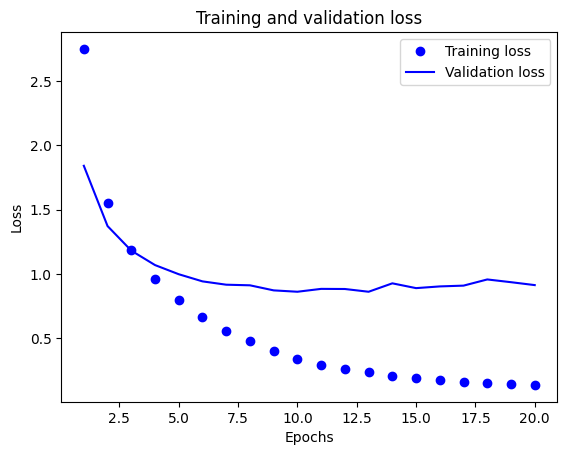

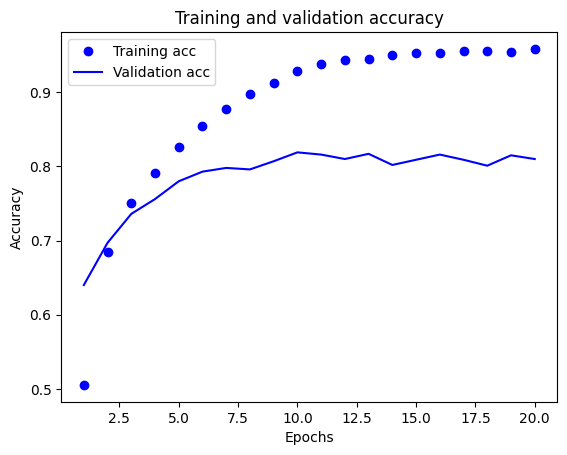

In [11]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Los graficos respaldan el analisis anterior, parece que a partir de la epoca 8 el modelo sobreentrena.

Ahora entrenar el modelo otra vez pero con todos los datos y cortando el entrenamiento en la epoca 9.

In [12]:
model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train,
          one_hot_train_labels,
          epochs=9,
          batch_size=512)

print("-------Evaluar--------")
results = model.evaluate(x_test, one_hot_test_labels)
results

2025-07-04 20:33:13.284977: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 359280000 exceeds 10% of free system memory.
2025-07-04 20:33:13.626714: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 359280000 exceeds 10% of free system memory.


Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4268 - loss: 3.1657
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6798 - loss: 1.5807
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7359 - loss: 1.1788
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7971 - loss: 0.9253
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8305 - loss: 0.7910
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8580 - loss: 0.6614
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8836 - loss: 0.5490
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9018 - loss: 0.4614
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9179 - loss: 0.3896
-------Evaluar--------
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7885 - loss: 0.9498


[0.9641116261482239, 0.7849510312080383]

Con la estrategia anterior se alcanza un accuracy de casi 80%.

Una estrategia random para este problema ronda un accuracy del 19% por lo que en definitiva se logra un avance relevante tomando esa linea de base.

In [13]:
import copy

test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
"""Notar que esta estrategia no es del todo random ya que al solo reordenar parte de una 
distribucion correcta. De cierta forma conoce que clases aparecen mas que otras."""
hits_array = np.array(test_labels) == np.array(test_labels_copy)
float(np.sum(hits_array)) / len(test_labels)

0.1794300979519145

## Analizar salida

Partir realizando una prediccion sobre los datos de test. Notar que cada predicion consta de un arreglo de 46 atributos.

In [14]:
predictions = model.predict(x_test)
print(predictions)
print(predictions.shape)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[1.1197795e-05 1.9089191e-05 3.5927243e-07 ... 1.8862142e-06
  3.4743530e-07 1.3980082e-06]
 [1.9020669e-04 3.1317536e-02 7.7208057e-03 ... 2.2852200e-06
  6.6638990e-05 2.2089774e-04]
 [4.2007347e-03 7.4640709e-01 1.3964145e-02 ... 4.0529214e-04
  4.2285243e-04 1.1128896e-03]
 ...
 [4.2832737e-05 4.2617417e-04 1.9511461e-05 ... 2.5119603e-05
  1.6513397e-05 2.9020248e-05]
 [2.9910211e-03 5.8555223e-02 1.1233912e-03 ... 3.5640286e-04
  3.9000210e-04 7.4823102e-04]
 [4.9363537e-04 5.1169038e-01 2.7173122e-02 ... 6.1352644e-04
  2.8413133e-04 2.5857047e-03]]
(2246, 46)


Los 46 valores de una misma prediccion suman 1.

In [15]:
np.sum(predictions[0])

np.float32(0.99999994)

La entrada con el valor mas grande en una predicción corresponde a la clase con la probabilidad mas alta.

In [16]:
np.argmax(predictions[0])

np.int64(3)

## Otros metodos de manejo de etiquetas

Otra forma de manejar las etiquetas es codificarlas como un vector de enteros de esta forma:

In [17]:
y_train_alt = np.array(train_labels)
y_test_alt = np.array(test_labels)
y_train_alt

array([ 3,  4,  3, ..., 25,  3, 25])

Esta codificación claramente es distinta del estilo ONE-HOT que se venia usando y de no manejarse bien implicara que las distintas categorias tienen un criterio de ordenación.

Una buena opcion para trabajar con los datos en este formato es cambiar la funcion de error (loss) por ´sparse_categorical_crossentropy´. Esta funcion de error hace lo mismo que ´categorical_crossentropy´ pero espera los datos en formato numerico en ves de ONE-HOT.

Para el usuario solo cambia la interfaz, ´sparse_categorical_crossentropy´ convierte el entero que recibe a una codificación ONE-HOT. Este comportamiento puede ser deseable cuando se tienen muchas clases ya que es mas eficiente en memoria.

In [18]:
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["acc"])

## Cuellos de botella arquitecturales (tamaño minimo)

Incorporar capas ocultas con menos unidades que la cantidad de clases que se predicen puede introducir cuellos de botella de información. 

Para tener una mejor idea se va a explorar un ejemplo de lo que ocurre en estas situaciones repitiendo el modelo que se uso antes pero reduciendo las unidades ocultas de las capas intermedias a 4:

2025-07-04 20:33:20.241678: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 319280000 exceeds 10% of free system memory.


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.0549 - loss: 3.7014 - val_accuracy: 0.0690 - val_loss: 3.4230
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0821 - loss: 3.3143 - val_accuracy: 0.0760 - val_loss: 3.1205
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0823 - loss: 2.9909 - val_accuracy: 0.1580 - val_loss: 2.8155
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3151 - loss: 2.6847 - val_accuracy: 0.4580 - val_loss: 2.5056
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4640 - loss: 2.3778 - val_accuracy: 0.4590 - val_loss: 2.2125
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4886 - loss: 2.0385 - val_accuracy: 0.4800 - val_loss: 1.9426
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5467 - loss: 1.7880 - val_accuracy: 0.6610 - val_loss: 1.7295
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6870 - loss: 1.5773 - val_accuracy: 0.6910 - v

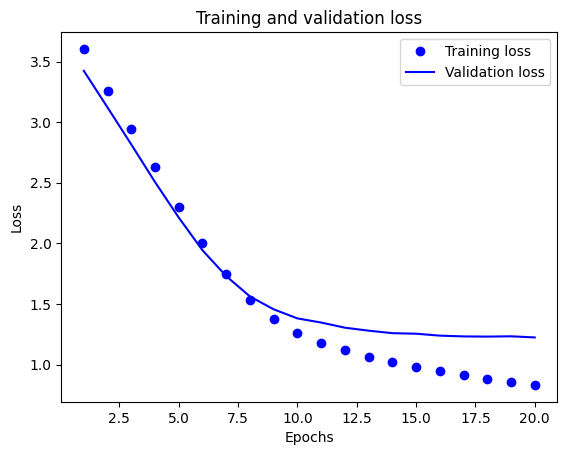

-------Evaluar--------
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7045 - loss: 1.2663


[1.3053404092788696, 0.6954585909843445]

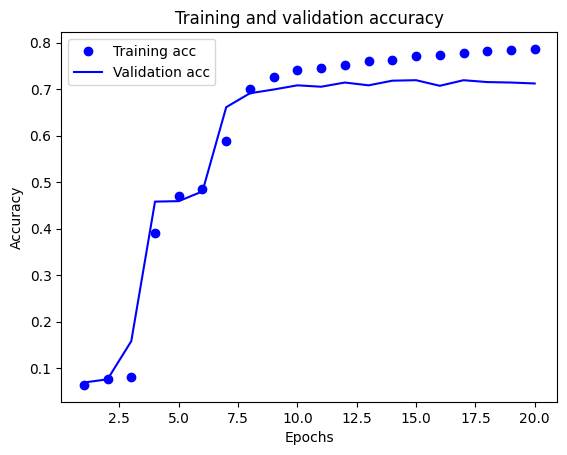

In [19]:
model = models.Sequential()
model.add(layers.Dense(64, 'relu', input_shape=(10000,)))
model.add(layers.Dense(4, 'relu'))
model.add(layers.Dense(46, 'softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=512,
          validation_data=(x_val,y_val))

import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

print("-------Evaluar--------")
results = model.evaluate(x_test, one_hot_test_labels)
results


La caida en el rendimiento ya era notable desde el infome del entrenamiento donde el pico de train antes en 98% ahra esta en 78%. En val esta en 70%. Y en test esta en 68%. Una caida total de un 10%.

La razon de esta caida es por que se esta intentando comprimir un monton de información (la informacion que permite distinguir a que clase corresponde un ejemplo) en un espacio intermedio de pocas dimensiones. La red puede codificar la MAYORIA de la información necesaria para la clasificación en un espacio de 8 dimensioenes. Pero, NO TODA.

In [20]:
model = models.Sequential()
model.add(layers.Dense(64, 'relu', input_shape=(10000,)))
model.add(layers.Dense(8, 'relu'))
model.add(layers.Dense(46, 'softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=512,
          validation_data=(x_val,y_val))

print("-------Evaluar--------")
results = model.evaluate(x_test, one_hot_test_labels)
results

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.0543 - loss: 3.5847 - val_accuracy: 0.2920 - val_loss: 2.8785
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2882 - loss: 2.6826 - val_accuracy: 0.5530 - val_loss: 2.2276
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5823 - loss: 2.0506 - val_accuracy: 0.5940 - val_loss: 1.7800
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6245 - loss: 1.5987 - val_accuracy: 0.6190 - val_loss: 1.5387
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6454 - loss: 1.3887 - val_accuracy: 0.6350 - val_loss: 1.4059
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6849 - loss: 1.2216 - val_accuracy: 0.6720 - val_loss: 1.3237
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7353 - loss: 1.0829 - val_accuracy: 0.7110 - val_loss: 1.2520
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7569 - loss: 1.0243 - val_accuracy: 0.7210 - v

[1.1640368700027466, 0.7453250288963318]

## Mas experimentos

### Mas Unidades

Antes se experimento disminuyendo el tamaño de las capas ocultas. Experimentar que ocurre cuando estas se hacen mas grandes.

#### 32 unidades

In [21]:
model = models.Sequential()
model.add(layers.Dense(64, 'relu', input_shape=(10000,)))
model.add(layers.Dense(32, 'relu'))
model.add(layers.Dense(46, 'softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=512,
          validation_data=(x_val,y_val))

print("-------Evaluar--------")
results = model.evaluate(x_test, one_hot_test_labels)
results

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.1588 - loss: 3.4269 - val_accuracy: 0.5870 - val_loss: 2.3183
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6241 - loss: 2.0605 - val_accuracy: 0.6840 - val_loss: 1.6163
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7175 - loss: 1.4384 - val_accuracy: 0.7210 - val_loss: 1.3443
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7667 - loss: 1.1389 - val_accuracy: 0.7330 - val_loss: 1.2021
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7997 - loss: 0.9558 - val_accuracy: 0.7680 - val_loss: 1.1200
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8355 - loss: 0.8037 - val_accuracy: 0.7880 - val_loss: 1.0430
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8574 - loss: 0.6872 - val_accuracy: 0.7980 - val_loss: 0.9881
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8745 - loss: 0.6027 - val_accuracy: 0.7890 - v

[1.0491936206817627, 0.7867319583892822]

Con 32 unidades en la capa intermedia ya se obtiene un rendimiento comparable al que se obtenia con 64.

#### 128 unidades

In [22]:
model = models.Sequential()
model.add(layers.Dense(64, 'relu', input_shape=(10000,)))
model.add(layers.Dense(128, 'relu'))
model.add(layers.Dense(46, 'softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=512,
          validation_data=(x_val,y_val))

print("-------Evaluar--------")
results = model.evaluate(x_test, one_hot_test_labels)
results

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.4154 - loss: 3.0996 - val_accuracy: 0.6350 - val_loss: 1.7178
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6656 - loss: 1.5636 - val_accuracy: 0.6990 - val_loss: 1.3390
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7416 - loss: 1.1570 - val_accuracy: 0.7400 - val_loss: 1.1426
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7911 - loss: 0.9388 - val_accuracy: 0.7650 - val_loss: 1.0433
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8330 - loss: 0.7601 - val_accuracy: 0.7960 - val_loss: 0.9573
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8641 - loss: 0.6221 - val_accuracy: 0.8010 - val_loss: 0.9332
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8859 - loss: 0.5336 - val_accuracy: 0.8130 - val_loss: 0.8978
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9110 - loss: 0.4286 - val_accuracy: 0.8290 - 

[1.0874874591827393, 0.7889581322669983]

Con 128 unidades en la capa intermedia el resultado es comparable a con 32 y con 64. 

Una hipotesis que podria tener sentido es que la capa de entrada con solo 64 unidades esta haciendo de cuello de botella para la capa de 128 unidades limitando la cantidad de informacion que esta ultima es capas de codificar.

Para comprobar esto se va a incrementar el tamaño de la 1ra capa a 128 neuronas. Si la premisa es cierta el accuracy deberia mejorar.

In [23]:
model = models.Sequential()
model.add(layers.Dense(128, 'relu', input_shape=(10000,)))
model.add(layers.Dense(128, 'relu'))
model.add(layers.Dense(46, 'softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=512,
          validation_data=(x_val,y_val))

print("-------Evaluar--------")
results = model.evaluate(x_test, one_hot_test_labels)
results

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.4234 - loss: 2.8584 - val_accuracy: 0.6660 - val_loss: 1.4720
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7090 - loss: 1.3107 - val_accuracy: 0.7240 - val_loss: 1.2105
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7824 - loss: 0.9836 - val_accuracy: 0.7760 - val_loss: 1.0447
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8361 - loss: 0.7545 - val_accuracy: 0.8020 - val_loss: 0.9637
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8721 - loss: 0.5869 - val_accuracy: 0.8070 - val_loss: 0.8857
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9109 - loss: 0.4361 - val_accuracy: 0.8200 - val_loss: 0.8605
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9258 - loss: 0.3419 - val_accuracy: 0.8120 - val_loss: 0.8585
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9406 - loss: 0.2784 - val_accuracy: 0.8180 - v

[1.1394833326339722, 0.784060537815094]

No hubo una mejora notable, puede que si lo haya si se incrementa mas el tamaño de la capa de entrada.

In [24]:
model = models.Sequential()
model.add(layers.Dense(256, 'relu', input_shape=(10000,)))
model.add(layers.Dense(128, 'relu'))
model.add(layers.Dense(46, 'softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=512,
          validation_data=(x_val,y_val))

print("-------Evaluar--------")
results = model.evaluate(x_test, one_hot_test_labels)
results

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.4494 - loss: 2.7671 - val_accuracy: 0.6640 - val_loss: 1.4099
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7193 - loss: 1.2547 - val_accuracy: 0.7430 - val_loss: 1.0935
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8159 - loss: 0.8493 - val_accuracy: 0.7500 - val_loss: 1.0579
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8519 - loss: 0.6822 - val_accuracy: 0.8020 - val_loss: 0.8991
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8915 - loss: 0.5018 - val_accuracy: 0.8210 - val_loss: 0.8362
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9254 - loss: 0.3557 - val_accuracy: 0.8200 - val_loss: 0.8416
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9330 - loss: 0.2988 - val_accuracy: 0.8200 - val_loss: 0.8497
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9414 - loss: 0.2514 - val_accuracy: 0.8100 - v

[1.2451446056365967, 0.7658059000968933]

De hecho si ubo una mejora. Se lo puede intentar atribuir tanto a lo que se dijo antes pero de hecho es normal que un incremento en la complejidad suponga una mejora en los resultados.

En todo caso parece que el conjunto de datos no da lugar a mas mejoras solo incrementando la cantidad de unidades ocultas.

#### 256 unidad

Ahora se va a probar con un tamaño mas grande de capas intermedias para ver que efectos tiene.

In [28]:
model = models.Sequential()
model.add(layers.Dense(64, 'relu', input_shape=(10000,)))
model.add(layers.Dense(256, 'relu'))
model.add(layers.Dense(46, 'softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=512,
          validation_data=(x_val,y_val))

print("-------Evaluar--------")
results = model.evaluate(x_test, one_hot_test_labels)
results

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.4066 - loss: 3.0685 - val_accuracy: 0.6300 - val_loss: 1.6503
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6655 - loss: 1.5136 - val_accuracy: 0.6960 - val_loss: 1.3218
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7357 - loss: 1.1449 - val_accuracy: 0.7630 - val_loss: 1.1332
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8048 - loss: 0.9013 - val_accuracy: 0.7840 - val_loss: 1.0215
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8365 - loss: 0.7207 - val_accuracy: 0.7850 - val_loss: 0.9711
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8626 - loss: 0.5998 - val_accuracy: 0.8020 - val_loss: 0.9302
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8917 - loss: 0.4824 - val_accuracy: 0.8180 - val_loss: 0.8799
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9198 - loss: 0.3753 - val_accuracy: 0.8040 - v

[1.1200467348098755, 0.7889581322669983]

El resultado apenas varia independientemente del tamaño de la capa lineal inicial. El pico esta en 64 con accuracy = 78%

### 1 Capa oculta

Repetir el experimento anterior con una sola capa oculta.

In [31]:
model = models.Sequential()
model.add(layers.Dense(64, 'relu', input_shape=(10000,)))
model.add(layers.Dense(46, 'softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=512,
          validation_data=(x_val,y_val))

print("-------Evaluar--------")
results = model.evaluate(x_test, one_hot_test_labels)
results

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.4507 - loss: 3.2171 - val_accuracy: 0.6460 - val_loss: 2.0185
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6785 - loss: 1.8049 - val_accuracy: 0.6980 - val_loss: 1.4868
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7392 - loss: 1.3105 - val_accuracy: 0.7420 - val_loss: 1.2305
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7885 - loss: 1.0388 - val_accuracy: 0.7730 - val_loss: 1.0851
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8276 - loss: 0.8273 - val_accuracy: 0.7960 - val_loss: 1.0020
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8588 - loss: 0.6995 - val_accuracy: 0.8080 - val_loss: 0.9429
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8826 - loss: 0.5884 - val_accuracy: 0.8150 - val_loss: 0.9026
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9007 - loss: 0.5041 - val_accuracy: 0.8210 - v

[0.8977540731430054, 0.7996438145637512]

Sorprendentemente el rendimiento mejoro haciendo que accuracy≈80% puede que este haya sido un caso de OVERFITTING donde un modelo mas simple logra generalizar mejor al conjunto de test.

Vale la pena inspeccionar los graficos:

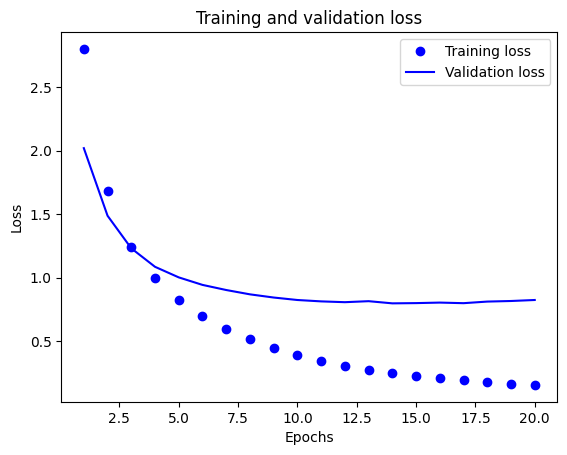

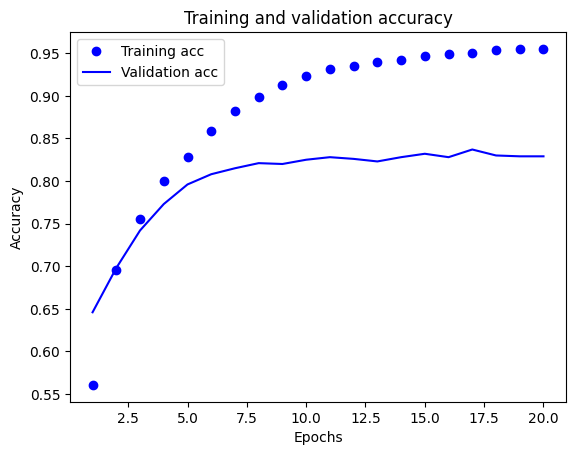

In [32]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

La curva es similar a lo que habia antes, aunque el punto de overfiting se esta atrazando al epoch 10.

Menos capas es favorable para el problema. En general parece que el overfiting se acelera con modelos mas complejos y se atraza con modelos mas sencillos. El atrazarlo es beneficioso ya que al dedicar mas EPOCHS se puede realizar un ajustar mas las variables.

### 3 Capas ocultas

Ahora añadir una capa mas a la arquitectura base de 2 capas para ver como evoluciona el entrenamiento.

In [39]:
model = models.Sequential()
model.add(layers.Dense(64, 'relu', input_shape=(10000,)))
model.add(layers.Dense(64, 'relu'))
model.add(layers.Dense(64, 'relu'))
model.add(layers.Dense(46, 'softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=512,
          validation_data=(x_val,y_val))

print("-------Evaluar--------")
results = model.evaluate(x_test, one_hot_test_labels)
results

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.3007 - loss: 3.3403 - val_accuracy: 0.5780 - val_loss: 1.8921
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6082 - loss: 1.7564 - val_accuracy: 0.6650 - val_loss: 1.4457
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6907 - loss: 1.3503 - val_accuracy: 0.7050 - val_loss: 1.2680
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7465 - loss: 1.1142 - val_accuracy: 0.7260 - val_loss: 1.1876
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7918 - loss: 0.9152 - val_accuracy: 0.7530 - val_loss: 1.0817
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8285 - loss: 0.7706 - val_accuracy: 0.7480 - val_loss: 1.0795
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8447 - loss: 0.6745 - val_accuracy: 0.7800 - val_loss: 1.0058
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8805 - loss: 0.5492 - val_accuracy: 0.7870 - v

[1.1964764595031738, 0.7796081900596619]

Luego de multiples ejecuciones se encontro que con 3 capas los resultados tienden a ser levemente peores o comparables a cuando habia solo 2 capas.

Se confirma parcialmente la suposicion de que mas complejidad perjudica este problema concreto.
Se realizan graficos para estudiar el entrenamiento:

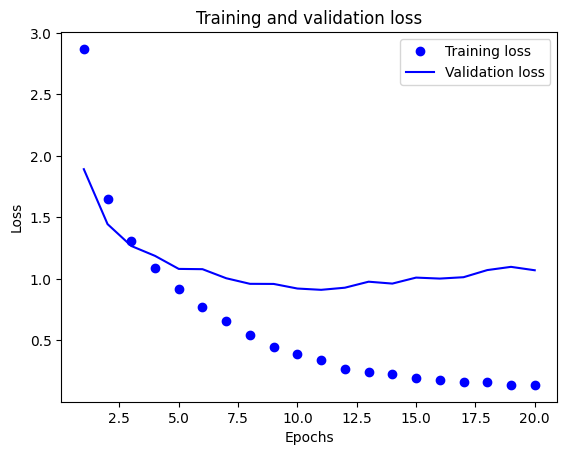

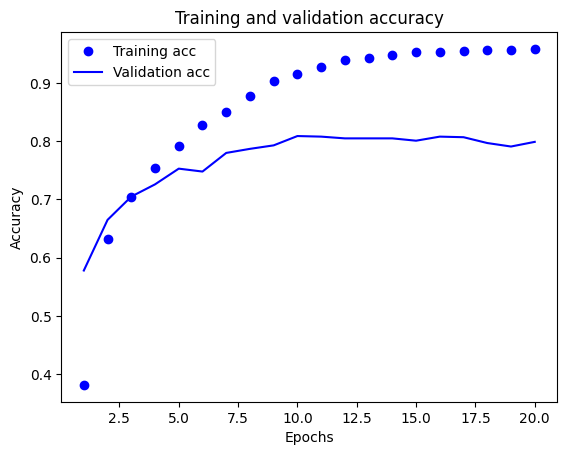

In [40]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

No se aprecia nada extraordinario. Se asume que el enfoque con 1 capa es la maxima complejidad que mejora la solución al problema mas que eso (unidades o capas) mantienen o empeoran el rendimiento.

Para MEJORAR EL RENDIMIENTO es muy probable que haya que MEJORAR LA REPRESENTACIÓN que se usa para códificar los datos o bien conseguir MAS DATOS.